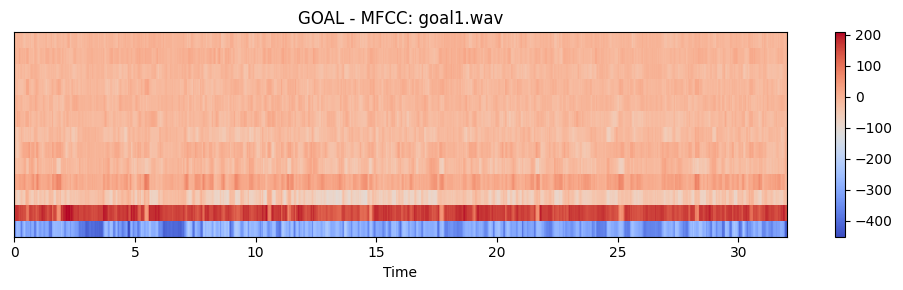

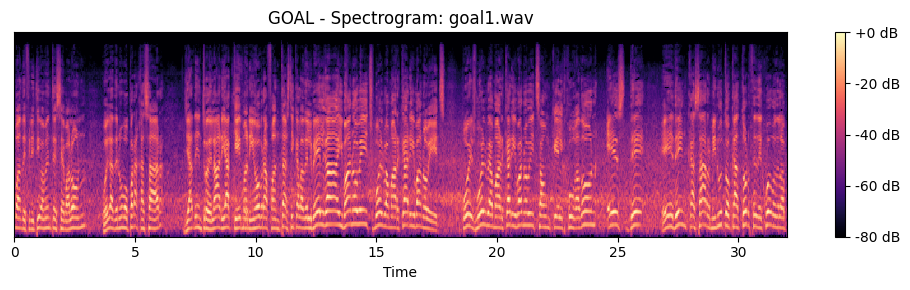

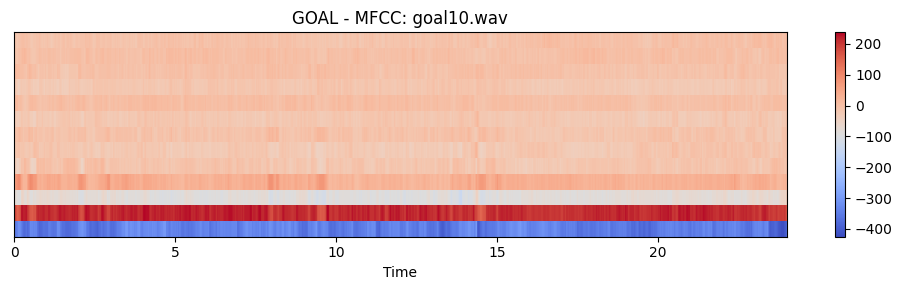

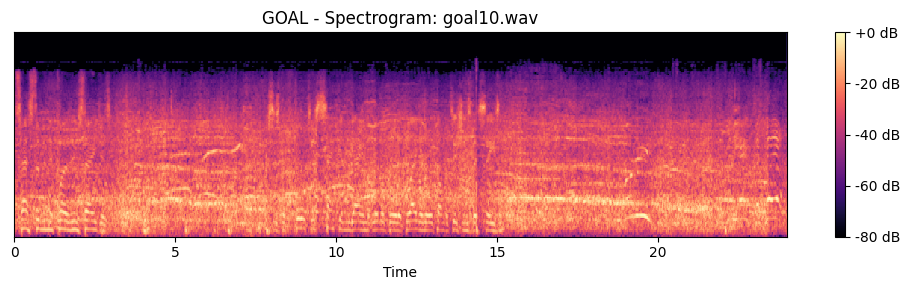

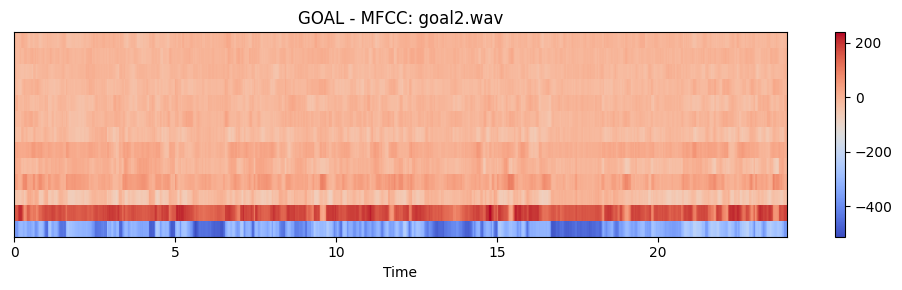

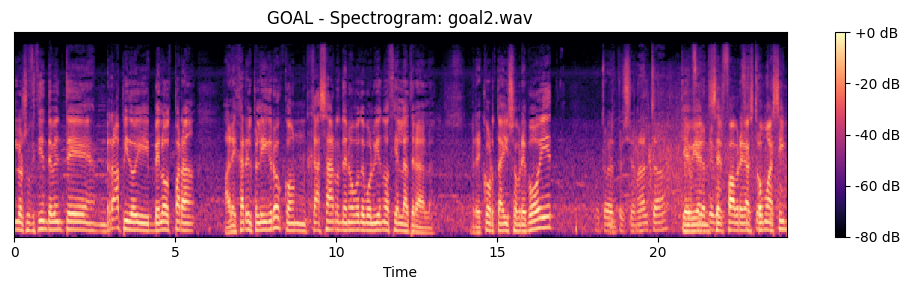

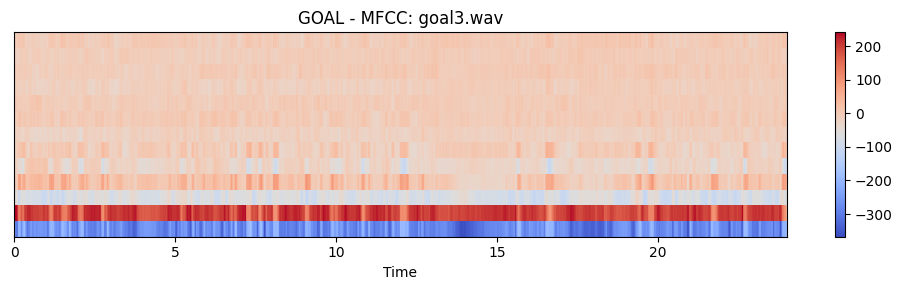

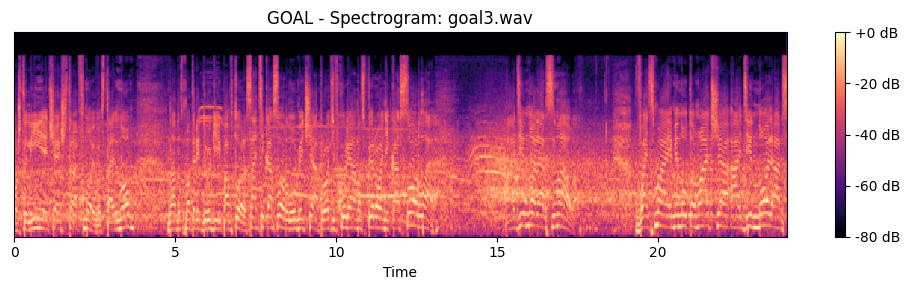

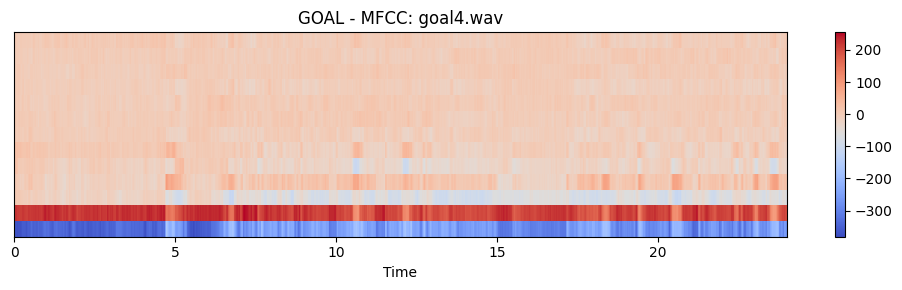

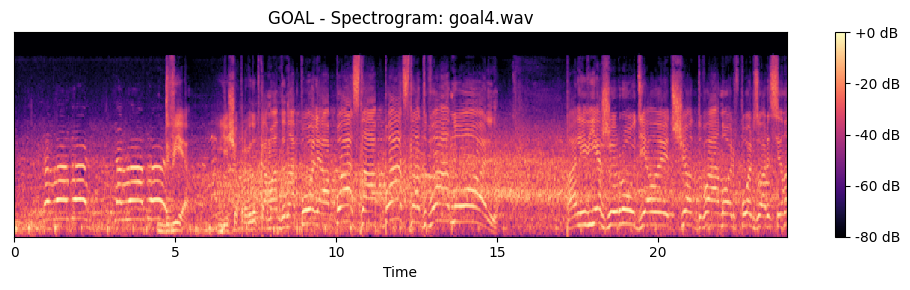

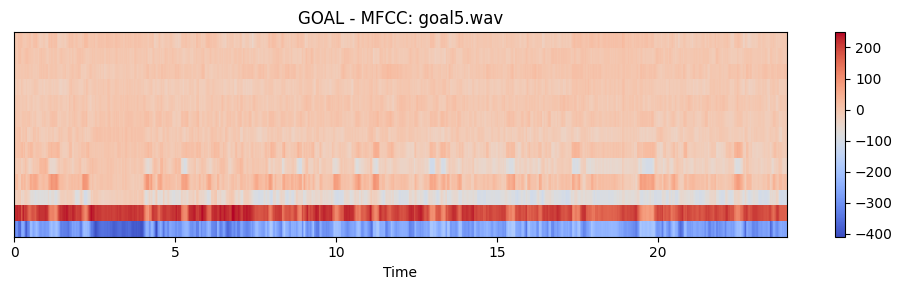

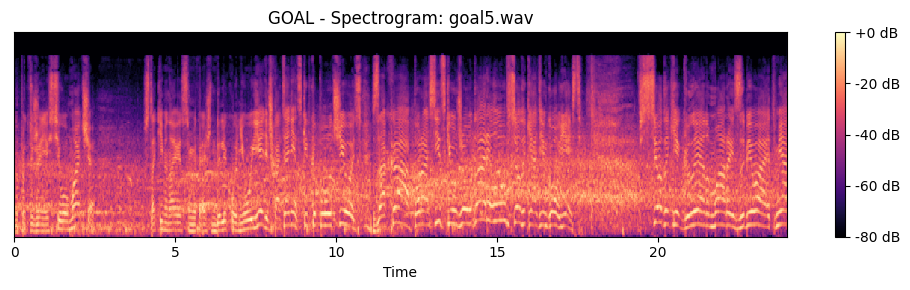

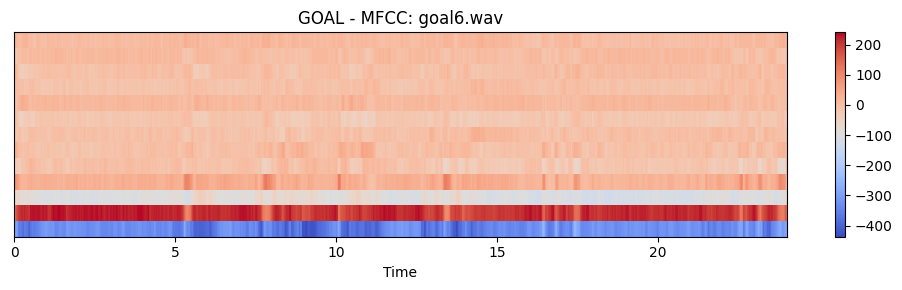

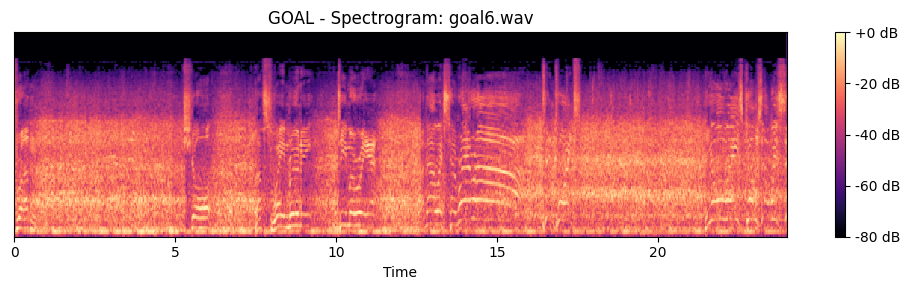

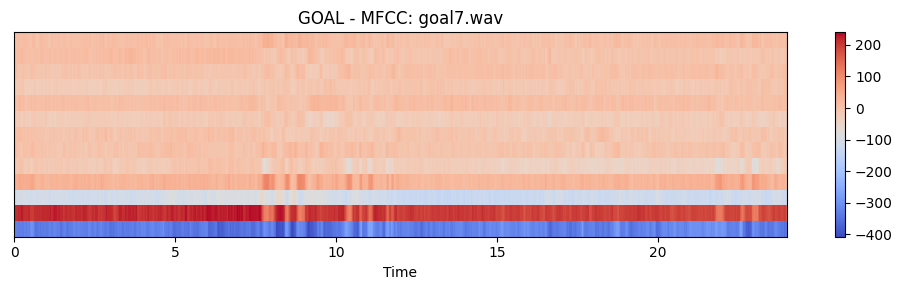

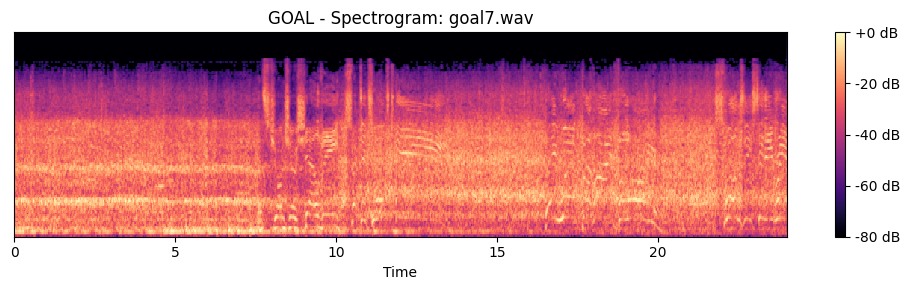

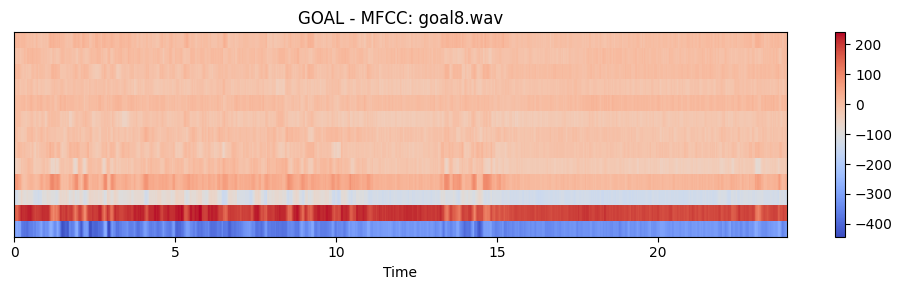

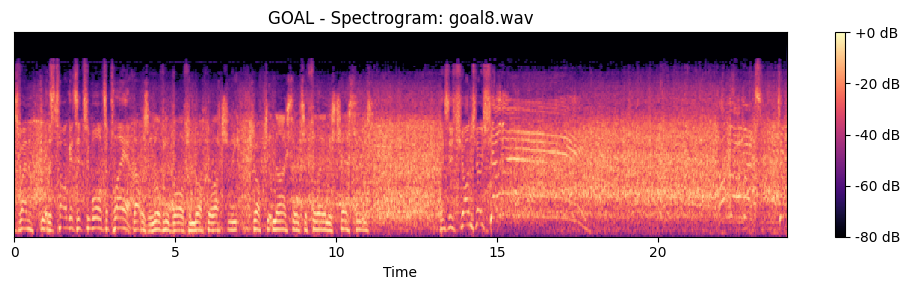

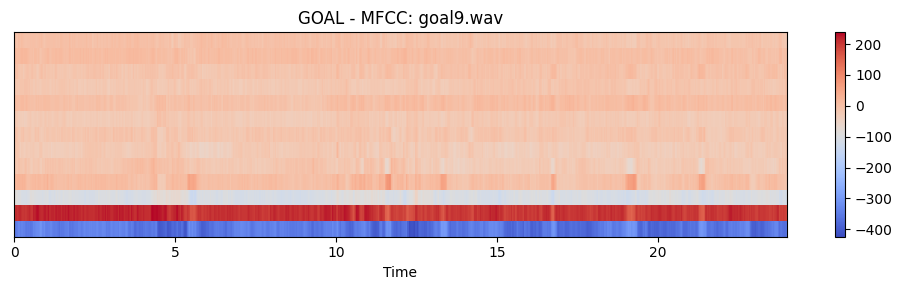

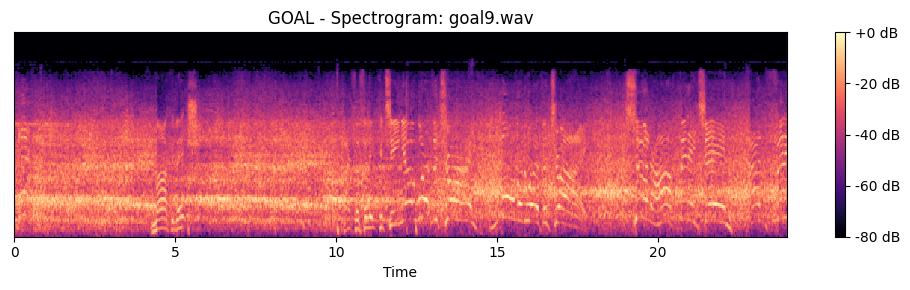

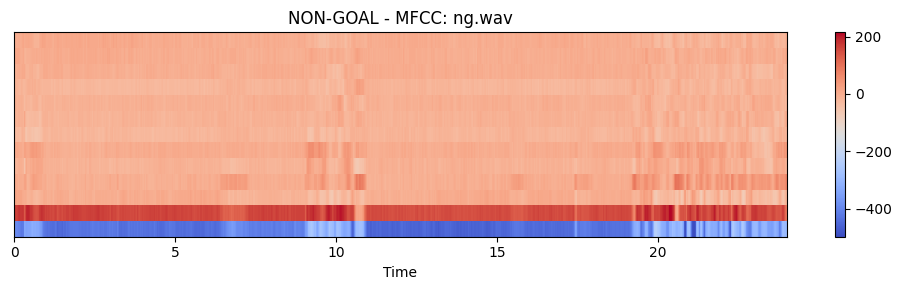

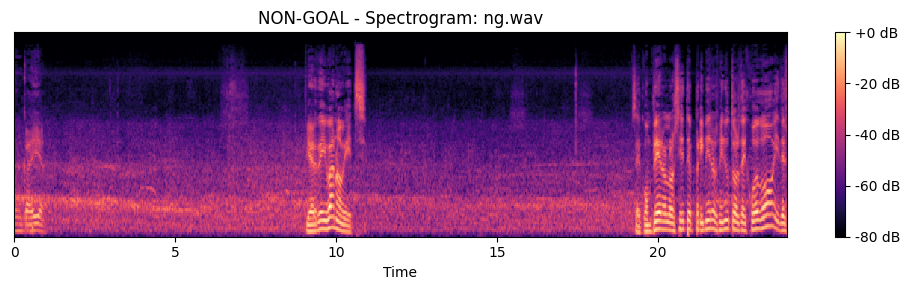

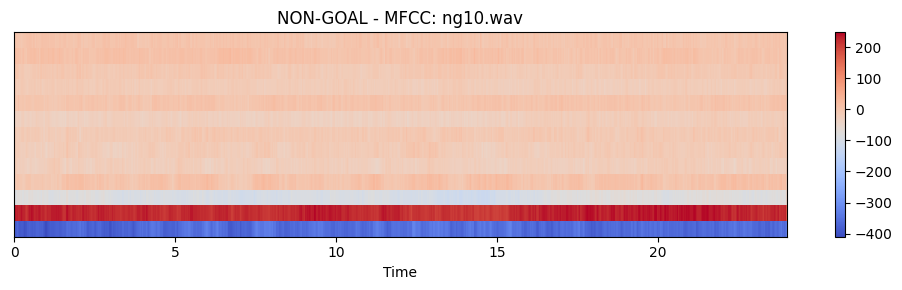

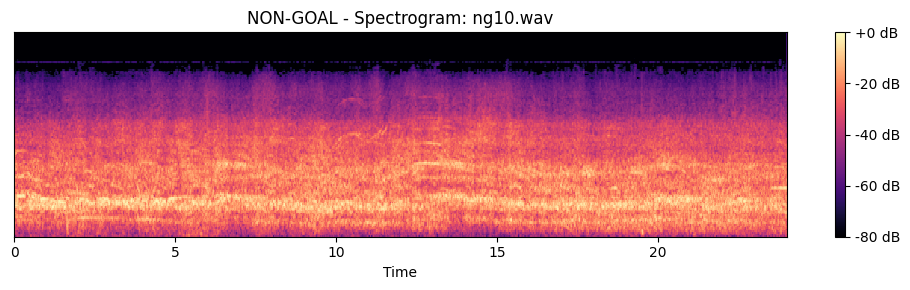

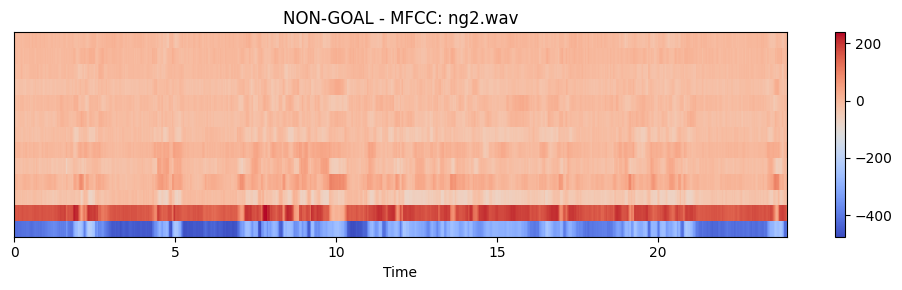

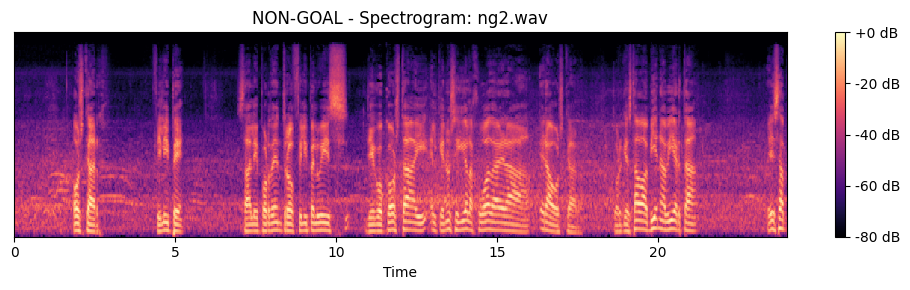

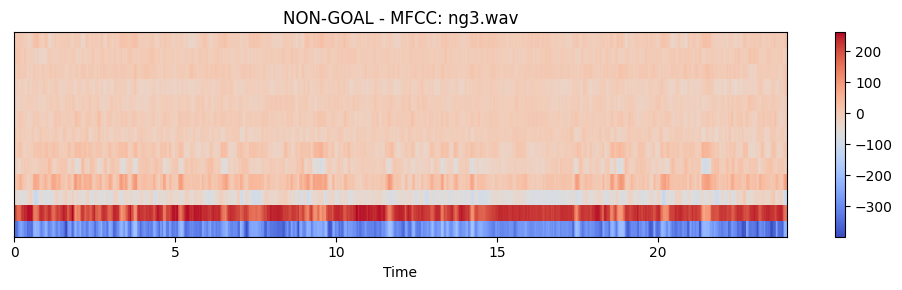

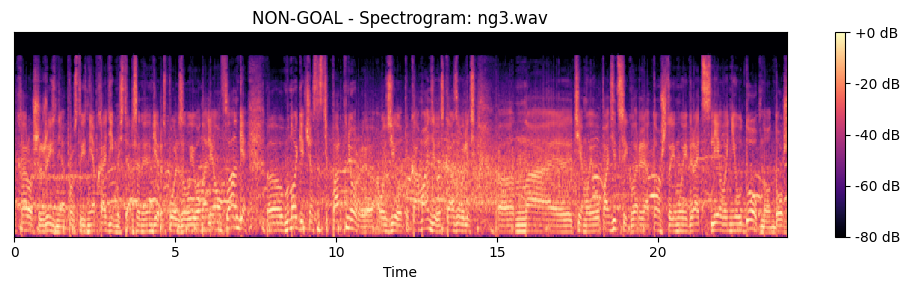

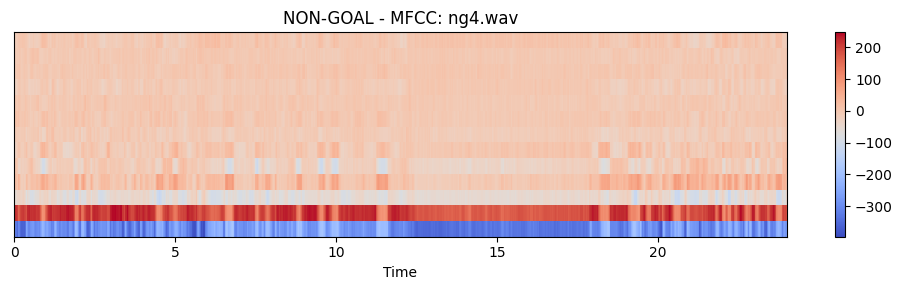

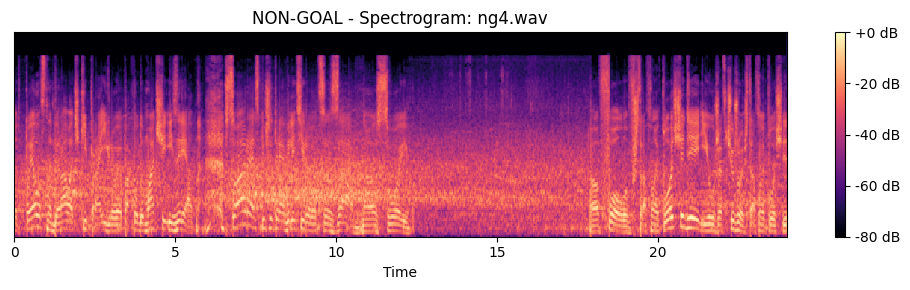

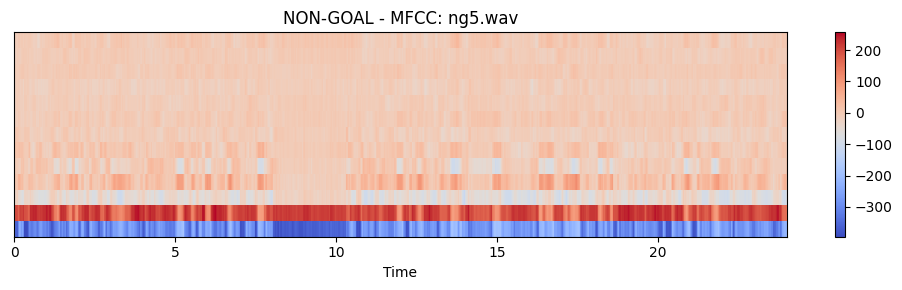

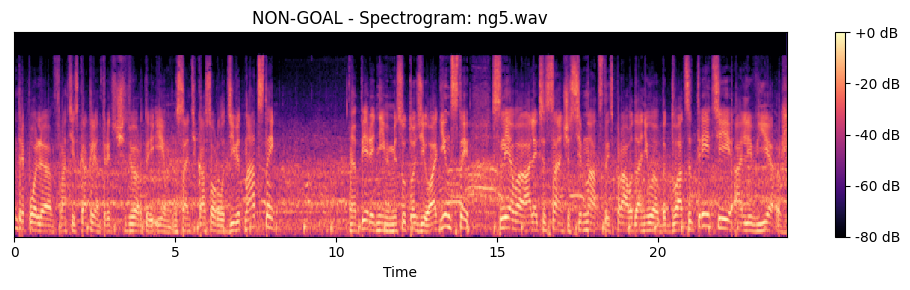

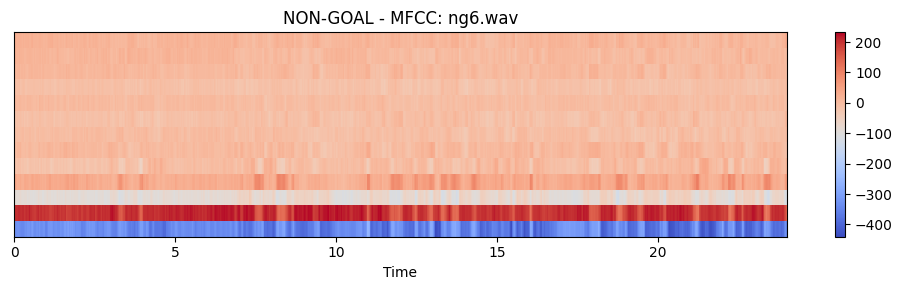

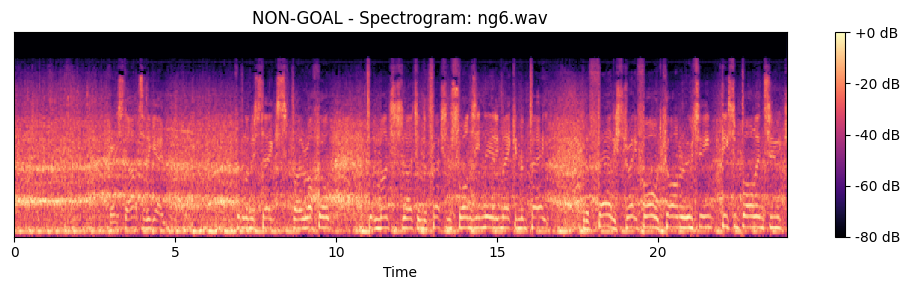

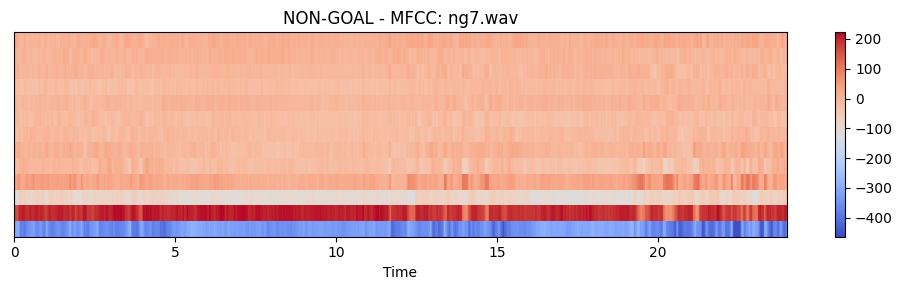

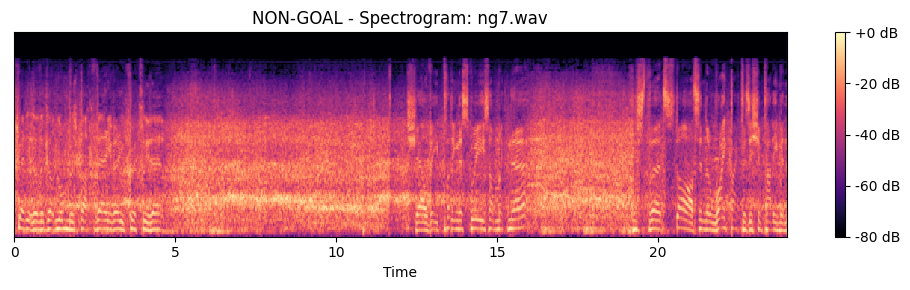

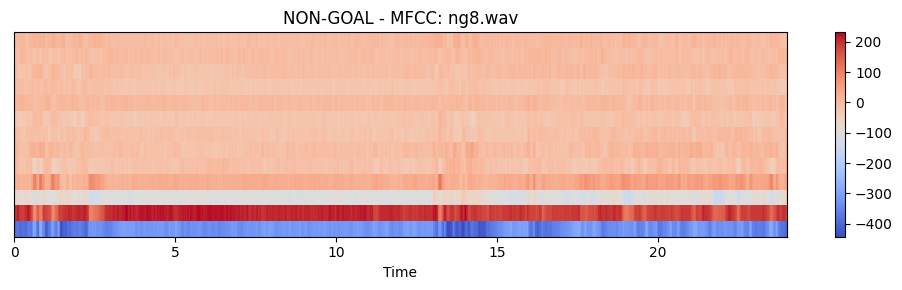

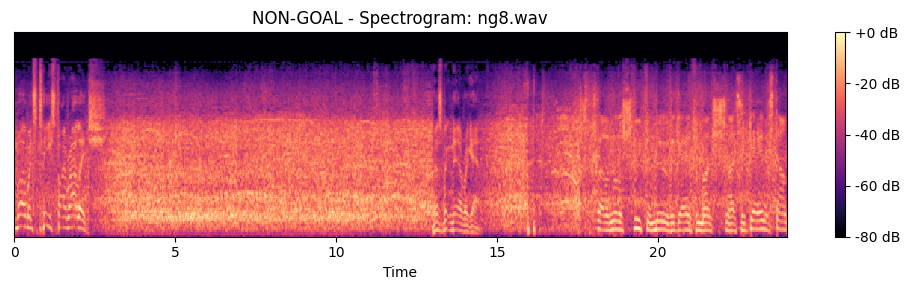

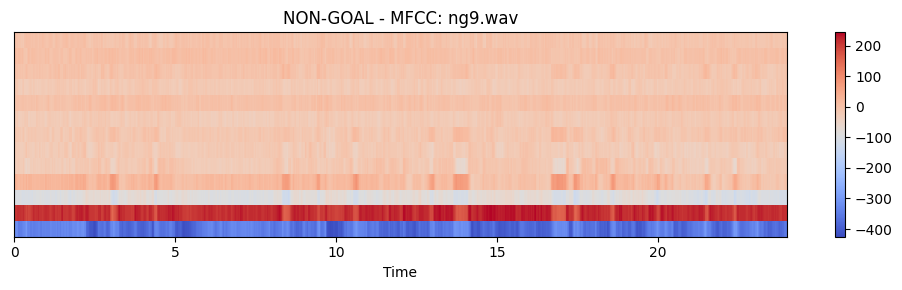

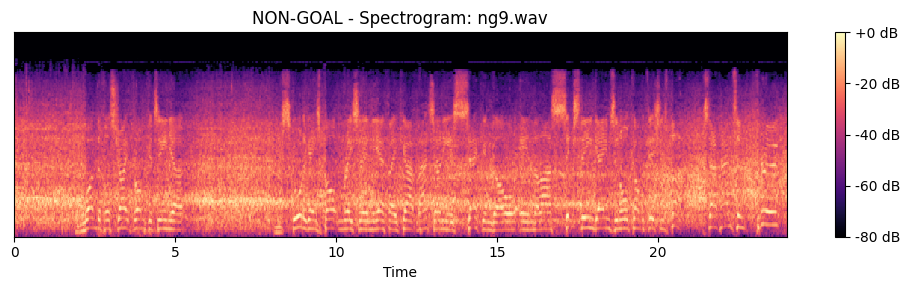

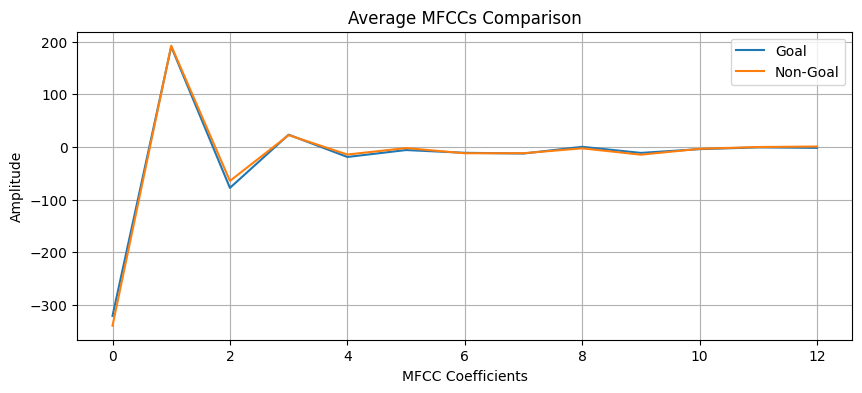

📊 Average Pitch (Hz)
  Goal     : 712.16
  Non-Goal : 612.69

⚡ Average Energy
  Goal     : 0.0298
  Non-Goal : 0.0254


In [4]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


folder_path = '/content/short_clips'


goal_files = sorted([f for f in os.listdir(folder_path) if f.startswith('goal') and f.endswith('.wav')])
nongoal_files = sorted([f for f in os.listdir(folder_path) if f.startswith('ng') and f.endswith('.wav')])

goal_stats = []
nongoal_stats = []


def analyze_audio(file_path):
    y, sr = librosa.load(file_path, sr=None)

    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfccs, axis=1)

    # Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr)
    S_dB = librosa.power_to_db(S, ref=np.max)

    # Pitch
    pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
    pitch = []
    for t in range(pitches.shape[1]):
        index = magnitudes[:, t].argmax()
        pitch.append(pitches[index, t])
    pitch = [p for p in pitch if p > 0]
    avg_pitch = np.mean(pitch) if pitch else 0

    # Average energy
    rms = librosa.feature.rms(y=y)[0]
    avg_energy = np.mean(rms)

    return mfcc_mean, avg_pitch, avg_energy, mfccs, S_dB

# Visualization and analysis
def process_clips(file_list, label):
    stats = []
    for fname in file_list:
        path = os.path.join(folder_path, fname)
        mfcc_mean, avg_pitch, avg_energy, mfccs, S_dB = analyze_audio(path)

        stats.append({
            'file': fname,
            'pitch': avg_pitch,
            'energy': avg_energy,
            'mfccs': mfcc_mean
        })


        plt.figure(figsize=(10, 3))
        librosa.display.specshow(mfccs, x_axis='time')
        plt.title(f'{label.upper()} - MFCC: {fname}')
        plt.colorbar()
        plt.tight_layout()
        plt.show()


        plt.figure(figsize=(10, 3))
        librosa.display.specshow(S_dB, x_axis='time', sr=22050, cmap='magma')
        plt.title(f'{label.upper()} - Spectrogram: {fname}')
        plt.colorbar(format='%+2.0f dB')
        plt.tight_layout()
        plt.show()

    return stats


goal_stats = process_clips(goal_files, label='goal')
nongoal_stats = process_clips(nongoal_files, label='non-goal')


df_goal = pd.DataFrame(goal_stats)
df_nongoal = pd.DataFrame(nongoal_stats)


avg_goal_pitch = df_goal['pitch'].mean()
avg_nongoal_pitch = df_nongoal['pitch'].mean()

avg_goal_energy = df_goal['energy'].mean()
avg_nongoal_energy = df_nongoal['energy'].mean()

avg_goal_mfcc = np.mean(np.stack(df_goal['mfccs'].values), axis=0)
avg_nongoal_mfcc = np.mean(np.stack(df_nongoal['mfccs'].values), axis=0)

# Plot average MFCCs
plt.figure(figsize=(10, 4))
plt.plot(avg_goal_mfcc, label='Goal')
plt.plot(avg_nongoal_mfcc, label='Non-Goal')
plt.title("Average MFCCs Comparison")
plt.xlabel("MFCC Coefficients")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()


print("📊 Average Pitch (Hz)")
print(f"  Goal     : {avg_goal_pitch:.2f}")
print(f"  Non-Goal : {avg_nongoal_pitch:.2f}\n")

print("⚡ Average Energy")
print(f"  Goal     : {avg_goal_energy:.4f}")
print(f"  Non-Goal : {avg_nongoal_energy:.4f}")


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import numpy as np

# Combine features and labels
X = np.array(df_goal['mfccs'].tolist() + df_nongoal['mfccs'].tolist())
y = np.array([1] * len(df_goal) + [0] * len(df_nongoal))  # 1 = Goal, 0 = Non-goal

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for 1D CNN (samples, time_steps, features)
X_scaled = X_scaled[..., np.newaxis]  # shape: (samples, 13, 1)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


In [7]:
# Build model
model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(13, 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train
history = model.fit(X_train, y_train, epochs=30, batch_size=4, validation_data=(X_test, y_test))



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 11, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 3, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,281 (130.00 KB)

 Trainable params: 33,281 (130.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.3667 - loss: 0.7154 - val_accuracy: 0.0000e+00 - val_loss: 0.7101
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5833 - loss: 0.6883 - val_accuracy: 0.5000 - val_loss: 0.6995
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4583 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6967
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6417 - loss: 0.6674 - val_accuracy: 0.7500 - val_loss: 0.7013
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6333 - loss: 0.6275 - val_accuracy: 0.5000 - val_loss: 0.7033
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7750 - loss: 0.6198 - val_accuracy: 0.7500 - val_loss: 0.7014
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6583 - loss: 0.6610 - val_accuracy: 0.7500 - val_loss: 0.7099
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5500 - loss: 0.6893 - val_accuracy: 0.7500 - val_loss: 0.7

In [8]:
# Evaluate accuracy
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\n🎯 Test Accuracy: {accuracy * 100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.7500 - loss: 1.3114

🎯 Test Accuracy: 75.00%


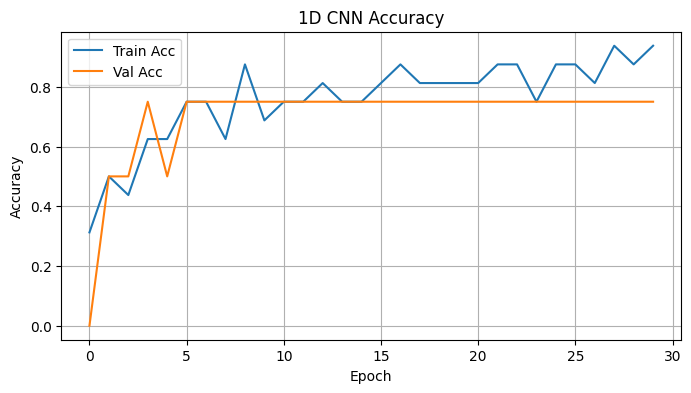

In [9]:

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('1D CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

 Classification Report:

              precision    recall  f1-score   support

    Non-Goal       0.67      1.00      0.80         2
        Goal       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



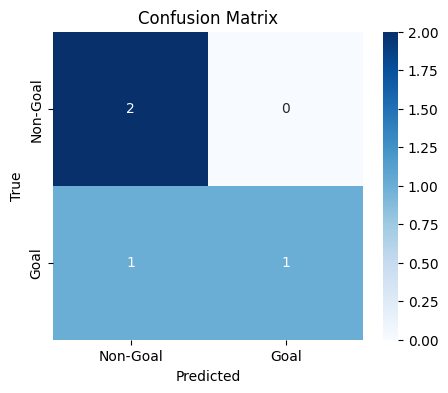

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

print("\n Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Non-Goal", "Goal"]))


cm = confusion_matrix(y_test, y_pred)
labels = ["Non-Goal", "Goal"]

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
